# Fourier SVG

## Sampling the SVG


Load an SVG, sample points from all paths, normalize them, and plot.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from svgpathtools import svg2paths2

In [5]:
def sample_svg(svg_file, num_samples=2000):
    """Sample points from an SVG file."""

    paths, attributes, svg_attributes = svg2paths2(svg_file)

    if not paths:
        raise ValueError("No paths found in the SVG file.")

    #print(paths)

    #decide how many points (counts) to sample from each path based on its length
    lengths = [path.length() for path in paths]
    total_length = sum(lengths)
    counts = [max(2, int(num_samples * (length / total_length))) for length in lengths]

    #adjust counts so we have exactly num_samples points
    while sum(counts) > num_samples:
        i = int(np.argmax(counts))
        if counts[i] > 2:
            counts[i] -= 1 #deletes path with largest current count, but ensures at least 2 points per path
        else:
            break

    while sum(counts) < num_samples:
        i = int(np.argmax(lengths))
        counts[i] += 1

    #print(counts)

    points = []
    #sample points from each path according to counts
    for path, count in zip(paths, counts):
        ts = np.linspace(0, 1, count, endpoint=False)
        for t in ts:
            point = path.point(t) #returns complex number, x + yi
            # SVG's y-axis points downward, flip y for Cartesian
            points.append((point.real, -point.imag))

    #normalize points to fit in a unit square centered at the origin
    points = np.array(points, float)
    points -= points.mean(axis=0, keepdims=True) #center
    points /= np.max(np.linalg.norm(points, axis=1)) #scale
    return points

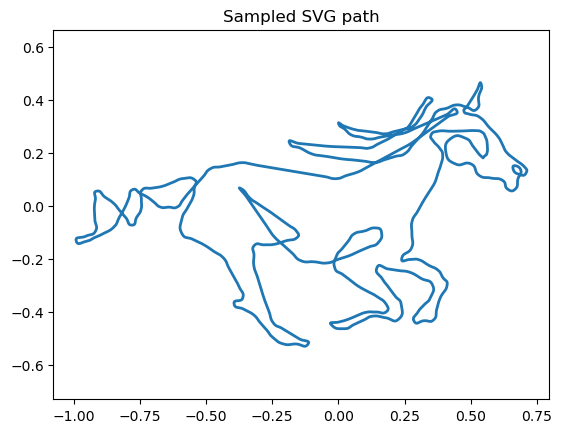

In [6]:
points = sample_svg('test_svg.svg', num_samples=2500)
plt.plot(points[:, 0], points[:, 1], linewidth=2)
plt.axis("equal")
plt.title("Sampled SVG path")
plt.show()

## Fouier Coefficients

Get k and c_k values, where c_k is complex coefficient and k is frequency

In [7]:
def fourier_components(points):
    """Compute Fourier components from sampled points.
    points: Nx2 array of (x, y) coordinates, centered and scaled
    returns: freqs (N,), coeffs (N,) complex Fourier coefficients
    z(t) = sum_k coeffs[k] * exp(2pi*i*freqs[k]*t)
    """
    z = points[:, 0] + 1j * points[:, 1] #convert to complex
    N = len(z)

    coeffs = np.fft.fft(z) / N #calculate DFT, normalize by N
    #cycles per d units, d is seconds/samples, so d=1/N, thus freqs are in cycles per sample
    freqs = np.fft.fftfreq(N, d=1.0/N).astype(int) #frequencies corresponding to coeff
    return freqs, coeffs

#### testing fourier_components function

In [15]:
N = 128
z = np.ones(N, dtype=complex) * (3 + 2j)
points = np.c_[z.real, z.imag]
freqs, coeffs = fourier_components(points)

coeffs
#should be just 3 + 2j at freq 0, and 0 for all other freqs

array([3.+2.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
      